# Afriskaut Dynasty Scouting League 2024 – Getting Started

This notebook walks through the basics of loading and exploring the Afriskaut open event data.

**Requirements:** `pandas`, `matplotlib` (both available via `pip install pandas matplotlib`)

**Before you begin:** Unzip `Datasets.zip` so that the `Datasets/` folder is in the same directory as this notebook.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## 1. List available matches

In [2]:
datasets_path = "Datasets"
match_ids = sorted(os.listdir(datasets_path))
print(f"Found {len(match_ids)} matches")
print(match_ids[:10])  # preview first 10

Found 137 matches
['65ecbe0aa6760f66b4f063e1', '65fc400c043ab4ea21f879ac', '65fc8000043ab4ea21f87d44', '6604866c2e4dbcfcb88f1908', '6605587a2e4dbcfcb88f2381', '6605bd89307e1fbe0c4c85c9', '6606b2e0aecc56823e307e7f', '660d3efdb0dd27e265dc1e2d', '660e3eebf1cddbb67c7d0ff0', '660f99dc0b4eb3501879a416']


## 2. Load a single match

Pick any MatchID from the list above. We'll load both the metadata and the events.

In [39]:
# Change this to any MatchID from the list above
match_id = '6605587a2e4dbcfcb88f2381' #Example MatchID

match_dir = os.path.join(datasets_path, match_id)

# Load match metadata
with open(os.path.join(match_dir, "match.json")) as f:
    match = json.load(f)

print(f"Match: {match.get('home_team_string')} vs {match.get('away_team_string')}")

Match: B.e. Arena vs Leal Fa 


In [40]:
# Load events (JSONL format — one event per line)
events = []
with open(os.path.join(match_dir, "events.jsonl")) as f:
    for line in f:
        line = line.strip()
        if line:
            events.append(json.loads(line))

df = pd.DataFrame(events)
print(f"Total events: {len(df)}")
print(f"Columns: {list(df.columns)}")

Total events: 890
Columns: ['_id', 'match_id', 'competition_id', 'season_id', 'team_id', 'player_id', 'isHome', 'event_outcome', 'event_name', 'event_type', 'player_number', 'event_direction', 'event_start_time', 'event_stop_time', 'event_start_x', 'event_start_y', 'event_end_x', 'event_end_y', 'event_clip_url', 'updatedAt', 'event_half', 'player_position', 'player_role']


## 3. Explore event types

In [42]:
# Column names - adjust these if your specific JSON schema differs
event_name_col = "event_name"
event_type_col = "event_type"
event_outcome_col = "event_outcome" 

# Verify all columns exist before processing
required_cols = [event_type_col, event_name_col, event_outcome_col]
if all(col in df.columns for col in required_cols):
    print(f"Summary of Match Events (Type > Name > Outcome):")
    print("-" * 75)
    
    # Grouping by all three dimensions to see the breakdown of results
    summary = (
        df.groupby([event_type_col, event_name_col, event_outcome_col])
        .size()
        .reset_index(name='counts')
        .sort_values(by=[event_type_col, 'counts'], ascending=[True, False])
    )
    
    # Using to_string(index=False) for a clean, table-like output
    print(summary.to_string(index=False))
else:
    missing = [col for col in required_cols if col not in df.columns]
    print(f"Error: Could not find columns: {missing}")
    print(f"Available columns in your data: {list(df.columns)}")

Summary of Match Events (Type > Name > Outcome):
---------------------------------------------------------------------------
       event_type   event_name            event_outcome  counts
      AERIAL_DUEL         DUEL               SUCCESSFUL      11
      AERIAL_DUEL         DUEL             UNSUCCESSFUL       4
 BALL_PROGRESSION   POSSESSION                                4
            BLOCK  DEF_ACTIONS                                9
            CATCH   GK_ACTIONS                   SIMPLE      10
    CLAIMED_CROSS   GK_ACTIONS                                1
        CLEARANCE  DEF_ACTIONS           UNDER_PRESSURE      39
          DRIBBLE   POSSESSION               SUCCESSFUL      22
          DRIBBLE   POSSESSION             UNSUCCESSFUL       3
             FOUL  DEF_ACTIONS                 OPP_HALF      17
             FOUL  DEF_ACTIONS                 OWN_HALF      10
             FOUL         CARD                   YELLOW       4
         FOUL_WON   POSSESSION             

## 4. Filter for a specific event type

Replace `"Pass"` below with any event type from the output above. Consult `Afriskaut Event Map - 2024.pdf` for all event definitions.

In [43]:
target_event = "GOAL"  # change this to any event type in the dataset, refer to '"Afriskaut Event Map - 2024.pdf"

filtered = df[df[event_name_col] == target_event].copy()
print(f"Found {len(filtered)} '{target_event}' events")
filtered.head()

Found 5 'GOAL' events


,_id,match_id,competition_id,season_id,team_id,player_id,isHome,event_outcome,event_name,event_type,...,event_stop_time,event_start_x,event_start_y,event_end_x,event_end_y,event_clip_url,updatedAt,event_half,player_position,player_role
276,6696b96494db57ed64191315,6605587a2e4dbcfcb88f2381,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,658d1ccd07b7d286330cdd16,65fc20a9043ab4ea21f877cf,1,SHOT,GOAL,INSIDE_BOX,...,00:11:25,467,130,497,146,https://media.naemoapp.com/669047b6ecef799cab8...,2024-07-17T16:58:54.835000,1,Forward,Center Forward
277,6696b96494db57ed641913e3,6605587a2e4dbcfcb88f2381,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,658d1ccd07b7d286330cdd16,65fc2d76043ab4ea21f8793f,1,SHOT,GOAL,INSIDE_BOX,...,01:01:32,76,125,2,192,https://media.naemoapp.com/669047b6ecef799cab8...,2024-07-17T16:58:58.633000,2,Forward,Left Winger
278,6630e634a0a423885ddfe448,6605587a2e4dbcfcb88f2381,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,65edf5f8c1d4f4a38095d87e,65ef067bc1d4f4a38095f1f6,2,SHOT,GOAL,INSIDE_BOX,...,00:24:07,30,138,2,166,https://media.naemoapp.com/6605587a2e4dbcfcb88...,2024-05-02T16:19:42.370000,1,Forward,"Center Forward,Supporting Striker,Right Winger..."
279,6630e634a0a423885ddfe44e,6605587a2e4dbcfcb88f2381,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,65edf5f8c1d4f4a38095d87e,65ef067bc1d4f4a38095f1f6,2,PENALTY,GOAL,INSIDE_BOX,...,00:28:33,60,175,8,186,https://media.naemoapp.com/6605587a2e4dbcfcb88...,2024-05-02T16:19:42.514000,1,Forward,"Center Forward,Supporting Striker,Right Winger..."
280,6630e634a0a423885ddfe4cb,6605587a2e4dbcfcb88f2381,658a93a1dca4b280f2be6485,658bf4aedad0e634df942e48,65edf5f8c1d4f4a38095d87e,65ef0d20c1d4f4a38095f2b2,2,SHOT,GOAL,INSIDE_BOX,...,01:02:42,479,129,498,150,https://media.naemoapp.com/6605587a2e4dbcfcb88...,2024-05-02T16:19:44.804000,2,Forward,"Left Winger,Right Winger"


## 5. Plot events on the pitch

The Afriskaut pitch coordinate system uses:
- X axis (length): 0 → 497
- Y axis (width): 0 → 328
- Origin `(0,0)` is the top-left corner

Adjust `x_col` and `y_col` below to match the coordinate field names in your data.

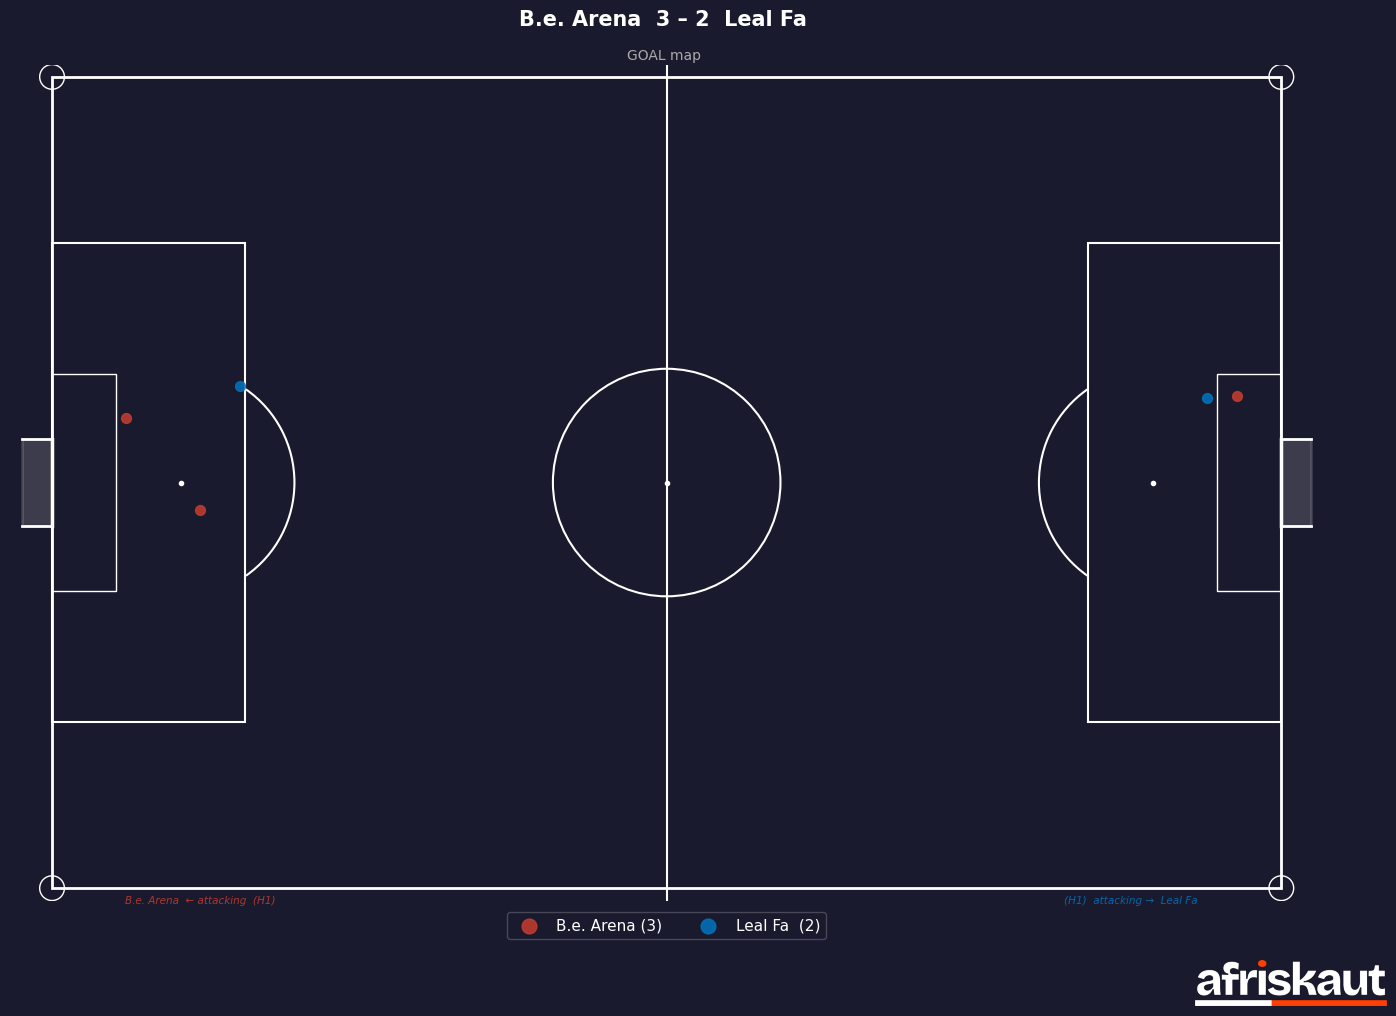

Plotted 5 'GOAL' events  (3 home · 2 away)


In [45]:
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ── Config ────────────────────────────────────────────────────────────────
x_col    = "event_start_x"
y_col    = "event_start_y"
time_col = "event_start_time"
team_col = "team_id"

PITCH_LENGTH = 497
PITCH_WIDTH  = 328

GOAL_WIDTH = int(round(7.32 / 68 * PITCH_WIDTH))   # ≈ 35 units
GOAL_DEPTH = 12                                      # visual depth in coord units

# ── Half-time boundary ────────────────────────────────────────────────────
def to_seconds(t):
    try:
        h, m, s = str(t).split(":")
        return int(h) * 3600 + int(m) * 60 + int(s)
    except Exception:
        return 0

first_half_end    = to_seconds(match.get("first_half_end_time",    "00:45:00"))
second_half_start = to_seconds(match.get("second_half_start_time", "01:00:00"))
HALFTIME_MIDPOINT = (first_half_end + second_half_start) / 2

# ── Directions ────────────────────────────────────────────────────────────
def parse_direction(match_data):
    def normalise(s):
        s = str(s).lower().replace(" ", "").replace("-", "")
        return "ltr" if ("left" in s or s in ("ltr",)) else "rtl"
    if "home_team_starting_direction" in match_data and "away_team_starting_direction" in match_data:
        return normalise(match_data["home_team_starting_direction"]), normalise(match_data["away_team_starting_direction"])
    elif "team_starting_direction" in match_data:
        home = normalise(match_data["team_starting_direction"])
        return home, ("rtl" if home == "ltr" else "ltr")
    return "ltr", "rtl"

home_dir_h1, away_dir_h1 = parse_direction(match)

# ── Team info & colours ───────────────────────────────────────────────────
home_team_id   = str(match.get("home_team", ""))
away_team_id   = str(match.get("away_team", ""))
home_team_name = match.get("home_team_string", "Home")
away_team_name = match.get("away_team_string", "Away")
home_goals     = match.get("home_goals", "")
away_goals     = match.get("away_goals", "")

def _readable(hex_color, fallback):
    try:
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
        return fallback if (0.299*r + 0.587*g + 0.114*b) > 200 else hex_color
    except Exception:
        return fallback

HOME_COLOR = _readable(match.get("home_team_color", "#00d4ff"), "#00d4ff")
AWAY_COLOR = _readable(match.get("away_team_color", "#ff6b35"), "#ff6b35")

# ── Coord cast ────────────────────────────────────────────────────────────
def get_coords(row):
    try:
        return float(row[x_col]), float(row[y_col])
    except (TypeError, ValueError):
        return None, None

# ── Pitch drawing ─────────────────────────────────────────────────────────
def draw_pitch(ax, length=PITCH_LENGTH, width=PITCH_WIDTH):
    goal_y = (width - GOAL_WIDTH) / 2

    ax.set_facecolor("#2d7a2d")
    ax.set_xlim(-GOAL_DEPTH - 5, length + GOAL_DEPTH + 5)
    ax.set_ylim(width + 5, -5)   # invert: (0,0) top-left

    # --- Pitch outline
    ax.add_patch(patches.Rectangle(
        (0, 0), length, width,
        linewidth=2, edgecolor="white", facecolor="none", zorder=2
    ))

    # --- Halfway line
    ax.axvline(x=length / 2, color="white", linewidth=1.5, zorder=2)

    # --- Centre circle
    ax.add_patch(plt.Circle(
        (length / 2, width / 2), radius=46,
        color="white", fill=False, linewidth=1.5, zorder=2
    ))

    # --- Centre spot
    ax.plot(length / 2, width / 2, "o", color="white", markersize=3, zorder=3)

    # --- Penalty boxes
    box_depth = int(round(16.5 / 105 * length))
    box_width = int(round(40.3 / 68  * width))
    box_y     = (width - box_width) / 2
    for bx in [0, length - box_depth]:
        ax.add_patch(patches.Rectangle(
            (bx, box_y), box_depth, box_width,
            linewidth=1.5, edgecolor="white", facecolor="none", zorder=2
        ))

    # --- Six-yard boxes
    six_depth = int(round(5.5 / 105 * length))
    six_width = int(round(18.3 / 68  * width))
    six_y     = (width - six_width) / 2
    for bx in [0, length - six_depth]:
        ax.add_patch(patches.Rectangle(
            (bx, six_y), six_depth, six_width,
            linewidth=1, edgecolor="white", facecolor="none", zorder=2
        ))

    # --- Penalty spots
    pen_x = int(round(11 / 105 * length))
    ax.plot(pen_x,          width / 2, "o", color="white", markersize=3, zorder=3)
    ax.plot(length - pen_x, width / 2, "o", color="white", markersize=3, zorder=3)

    # --- Penalty arcs
    for cx in [pen_x, length - pen_x]:
        arc = patches.Arc(
            (cx, width / 2), width=92, height=92,
            angle=0, theta1=305, theta2=55,
            color="white", linewidth=1.5, zorder=2
        )
        if cx > length / 2:
            arc = patches.Arc(
                (cx, width / 2), width=92, height=92,
                angle=0, theta1=125, theta2=235,
                color="white", linewidth=1.5, zorder=2
            )
        ax.add_patch(arc)

    # --- Goalposts (left and right)
    for gx, anchor_x in [(0, -GOAL_DEPTH), (length, length)]:
        ax.add_patch(patches.Rectangle(
            (anchor_x, goal_y), GOAL_DEPTH, GOAL_WIDTH,
            linewidth=2, edgecolor="white", facecolor="#ffffff",
            alpha=0.15, zorder=1
        ))
        # Crossbar line
        ax.plot([anchor_x, anchor_x + GOAL_DEPTH], [goal_y, goal_y],
                color="white", linewidth=2, zorder=3)
        ax.plot([anchor_x, anchor_x + GOAL_DEPTH], [goal_y + GOAL_WIDTH, goal_y + GOAL_WIDTH],
                color="white", linewidth=2, zorder=3)
        # Back post line
        post_x = anchor_x if gx == length else anchor_x + GOAL_DEPTH
        ax.plot([post_x, post_x], [goal_y, goal_y + GOAL_WIDTH],
                color="white", linewidth=2.5, zorder=3)

    # --- Corner flags (small circles)
    for cx, cy in [(0,0), (length,0), (0,width), (length,width)]:
        ax.add_patch(plt.Circle((cx, cy), radius=5,
                                color="white", fill=False, linewidth=1, zorder=2))

    ax.set_aspect("equal")
    ax.axis("off")

# ── Plot ──────────────────────────────────────────────────────────────────
required_cols = {x_col, y_col, team_col, time_col}
missing_cols  = required_cols - set(filtered.columns)

if missing_cols:
    print(f"⚠️  Cannot plot — missing columns: {missing_cols}")
    print(f"   Available columns: {list(filtered.columns)}")
else:
    plot_data = filtered.copy()
    plot_data[["x_norm", "y_norm"]] = plot_data.apply(
        lambda r: pd.Series(get_coords(r)), axis=1
    )
    plot_data = plot_data.dropna(subset=["x_norm", "y_norm"])

    is_home_mask = plot_data[team_col].astype(str).str.strip() == home_team_id
    home_events  = plot_data[is_home_mask]
    away_events  = plot_data[~is_home_mask]

    # ── Figure layout
    fig = plt.figure(figsize=(16, 11), facecolor="#1a1a2e")
    ax  = fig.add_axes([0.05, 0.12, 0.90, 0.76])   # [left, bottom, width, height]

    draw_pitch(ax)

    ax.scatter(
        home_events["x_norm"], home_events["y_norm"],
        color=HOME_COLOR, s=50, alpha=0.85, zorder=4,
        label=f"{home_team_name} ({len(home_events)})"
    )
    ax.scatter(
        away_events["x_norm"], away_events["y_norm"],
        color=AWAY_COLOR, s=50, alpha=0.85, zorder=4,
        label=f"{away_team_name} ({len(away_events)})"
    )

    # ── Direction indicators inside pitch, near each goal end
    h1_home_arrow = "attacking →" if home_dir_h1 == "ltr" else "← attacking"
    h1_away_arrow = "attacking →" if away_dir_h1 == "ltr" else "← attacking"
    ax.text(60,  PITCH_WIDTH + 3, f"{home_team_name}  {h1_home_arrow}  (H1)",
            ha="center", va="top", color=HOME_COLOR, fontsize=7.5,
            alpha=0.85, style="italic")
    ax.text(PITCH_LENGTH - 60, PITCH_WIDTH + 3, f"(H1)  {h1_away_arrow}  {away_team_name}",
            ha="center", va="top", color=AWAY_COLOR, fontsize=7.5,
            alpha=0.85, style="italic")

    # ── Legend
    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.055),
        ncol=2,
        frameon=True,
        framealpha=0.2,
        facecolor="#1a1a2e",
        edgecolor="white",
        fontsize=11,
        markerscale=1.5,
        labelcolor="white"
    )

    # ── Title block (score + event type) — placed in figure space above axes
    fig.text(0.5, 0.93,
             f"{home_team_name}  {home_goals} – {away_goals}  {away_team_name}",
             ha="center", va="top",
             color="white", fontsize=15, fontweight="bold")
    fig.text(0.5, 0.895,
             f"{target_event} map ",
             ha="center", va="top",
             color="#aaaaaa", fontsize=10)

    # ── Afriskaut logo (bottom-right of figure)
    try:
        logo = mpimg.imread("Afriskaut.png")
        logo_ax = fig.add_axes([0.83, 0.01, 0.12, 0.07])
        logo_ax.imshow(logo)
        logo_ax.axis("off")
    except FileNotFoundError:
        fig.text(0.92, 0.02, "Afriskaut", ha="right", va="bottom",
                 color="#aaaaaa", fontsize=9, style="italic")

    plt.show()
    print(f"Plotted {len(plot_data)} '{target_event}' events  "
          f"({len(home_events)} home · {len(away_events)} away)")

## 6. Load all matches at once

If you want to work across the full dataset:

In [34]:
all_events = []

for mid in match_ids:
    events_path = os.path.join(datasets_path, mid, "events.jsonl")
    if not os.path.exists(events_path):
        continue
    with open(events_path) as f:
        for line in f:
            line = line.strip()
            if line:
                event = json.loads(line)
                event["match_id"] = mid  # tag each event with its match
                all_events.append(event)

all_df = pd.DataFrame(all_events)
print(f"Total events across all matches: {len(all_df)}")
print(f"Matches loaded: {all_df['match_id'].nunique()}")

Total events across all matches: 84214
Matches loaded: 136


---

## Next steps

- Consult `Afriskaut Event Map - 2024.pdf` for the full list of event types and their attributes
- Use `summary.csv` for a quick overview of event counts per match
- Use `Pitch Coordinates For Afriskaut Event Data.pdf` for a visual reference of the coordinate system

Built something with this data? Tag **Afriskaut** or reach out at [tayo@afriskaut.com](mailto:tayo@afriskaut.com)